<h1>Bank Marketing Dataset-VisualizationNotebook</h1>

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']=110
plt.rcParams['axes.titlesize']=13
plt.rcParams['axes.labelsize']=11
print("Libraries loaded.")

Libraries loaded.


<h2>2. Load Preprocessed Dataset</h2>


In [3]:
df_viz =pd.read_csv('final_preprocessed.csv')
print('shape:',df_viz.shape)
df_viz.head()

shape: (45211, 21)


,age,job,marital,education,default,balance,housing,loan,contact,day,...,duration,campaign,pdays,previous,poutcome,y,was_previously_contacted,month_num,age_group,balance_tier
0,58.0,management,married,tertiary,no,2143,yes,no,unknown,5,...,261,1,0,0,unknown,no,0,5,50-59,High
1,44.0,technician,single,secondary,no,29,yes,no,unknown,5,...,151,1,0,0,unknown,no,0,5,40-49,Low
2,33.0,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,...,76,1,0,0,unknown,no,0,5,30-39,Low
3,47.0,blue-collar,married,secondary,no,1506,yes,no,unknown,5,...,92,1,0,0,unknown,no,0,5,40-49,Medium
4,33.0,blue-collar,single,secondary,no,1,no,no,unknown,5,...,198,1,0,0,unknown,no,0,5,30-39,Low


In [8]:
df_viz.describe()

,age,balance,day,duration,campaign,pdays,previous,was_previously_contacted,month_num
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.868185,933.706974,15.806419,234.939307,2.392228,41.015195,0.580323,0.182633,6.144655
std,10.394895,1176.765369,8.322476,176.749932,1.600111,99.792615,2.303441,0.386369,2.408034
min,18.000000,-1962.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,0.000000,0.000000,0.000000,5.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,0.000000,0.000000,0.000000,6.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,0.000000,0.000000,0.000000,8.000000
max,70.500000,3462.000000,31.000000,643.000000,6.000000,871.000000,275.000000,1.000000,12.000000


In [9]:
df_viz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       45211 non-null  float64
 1   job                       45211 non-null  object 
 2   marital                   45211 non-null  object 
 3   education                 45211 non-null  object 
 4   default                   45211 non-null  object 
 5   balance                   45211 non-null  int64  
 6   housing                   45211 non-null  object 
 7   loan                      45211 non-null  object 
 8   contact                   45211 non-null  object 
 9   day                       45211 non-null  int64  
 10  month                     45211 non-null  object 
 11  duration                  45211 non-null  int64  
 12  campaign                  45211 non-null  int64  
 13  pdays                     45211 non-null  int64  
 14  previo

<h2>3.Target Variable Distribution(y)</h2>

<p>Understand class imbalance before any other analysis</p>

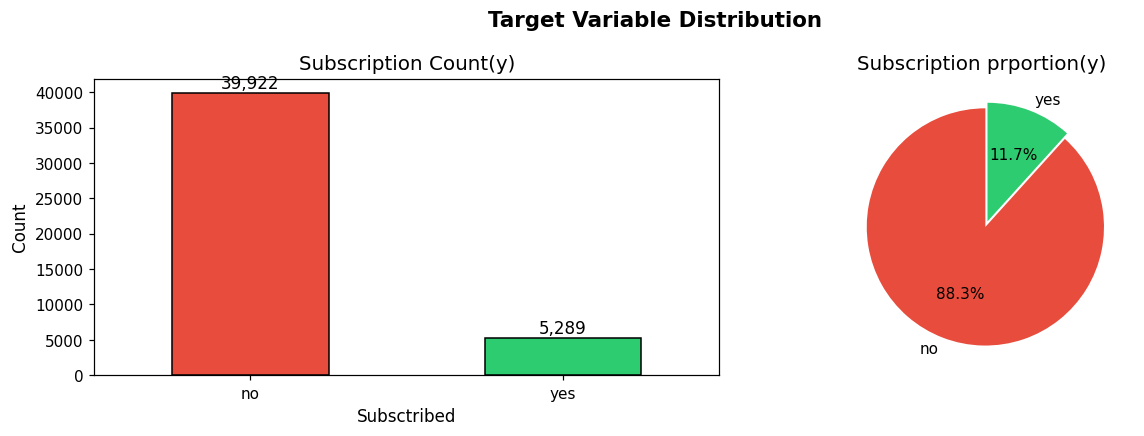

class Distribution:
y
no     39922
yes     5289
Name: count, dtype: int64

Class ratio(%):
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


In [23]:
fig , axes = plt.subplots(1, 2, figsize=(12,4))

df_viz['y'].value_counts().plot(kind='bar', ax=axes[0],
                                color=['#e74c3c','#2ecc71'],
                            edgecolor='black')
axes[0].set_title('Subscription Count(y)')
axes[0].set_xlabel('Subsctribed') 
axes[0].set_ylabel('Count') 
axes[0].tick_params(axis='x',rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center',va='bottom',fontsize=11)

df_viz['y'].value_counts().plot(kind='pie',ax=axes[1],
                                autopct='%1.1f%%',startangle=90,
                                colors=['#e74c3c','#2ecc71'],
                                explode=[0,0.05])
axes[1].set_title('Subscription prportion(y) ')
axes[1].set_ylabel('')

plt.suptitle('Target Variable Distribution',fontsize=14,fontweight='bold') 
plt.tight_layout()
plt.show()

print('class Distribution:') 
print(df_viz['y'].value_counts())
print('\nClass ratio(%):')
print(df_viz['y'].value_counts(normalize=True).mul(100).round(1))

<h2>4.Histogram -All Numerical Columns</h2>
<p>Qucik look at the distribution shape of every numeric feature.</p>

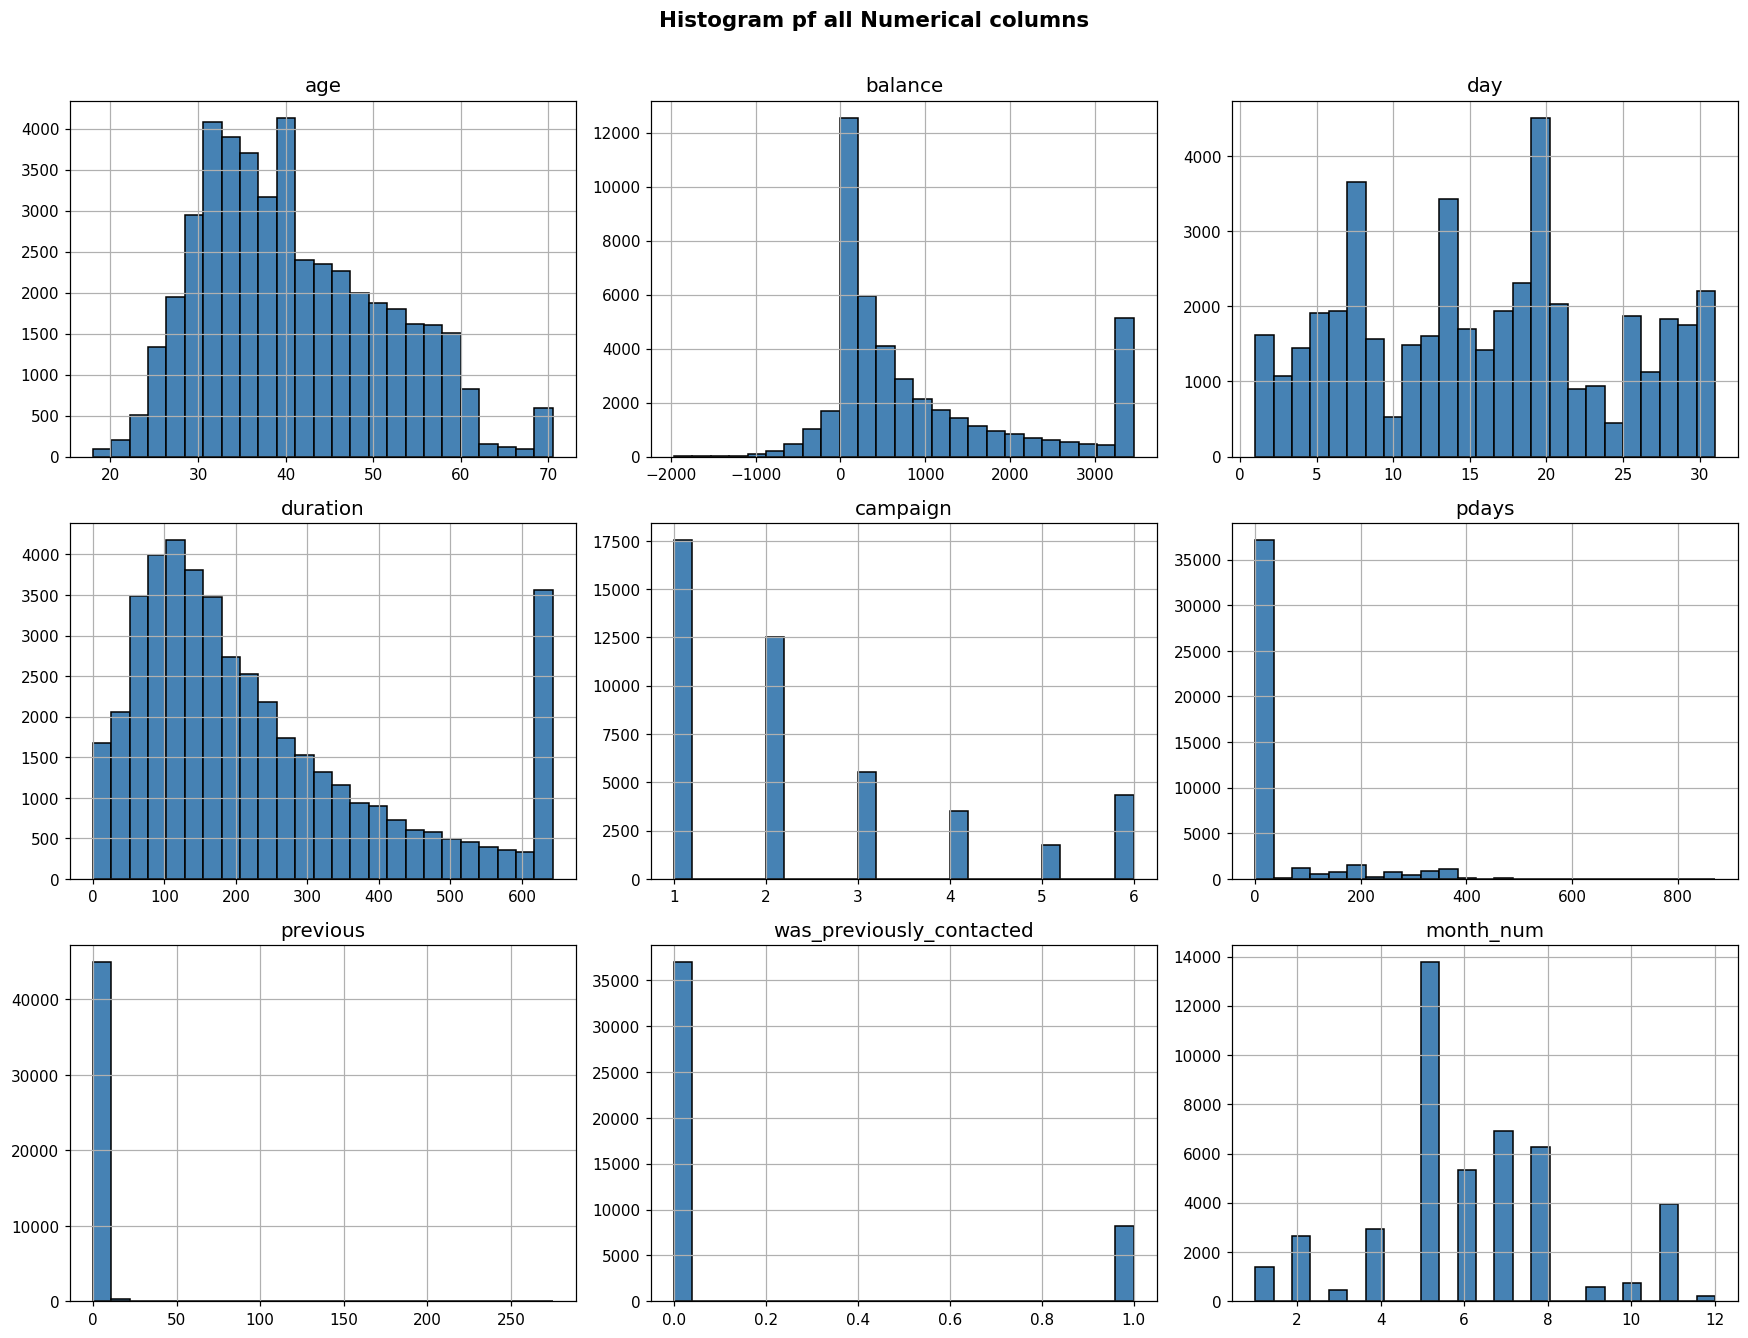

In [24]:
df_viz.hist(bins=25,figsize=(16,12),edgecolor='black' ,color='steelblue') 
plt.suptitle('Histogram pf all Numerical columns',fontsize=14, fontweight='bold',y=1.01)
plt.tight_layout()
plt.show()

<h2>5.Categorical Columns vs Target (y)</h2>
<p>For every vategorical column except(y) we plot subscription counts split by yes/no .</p>

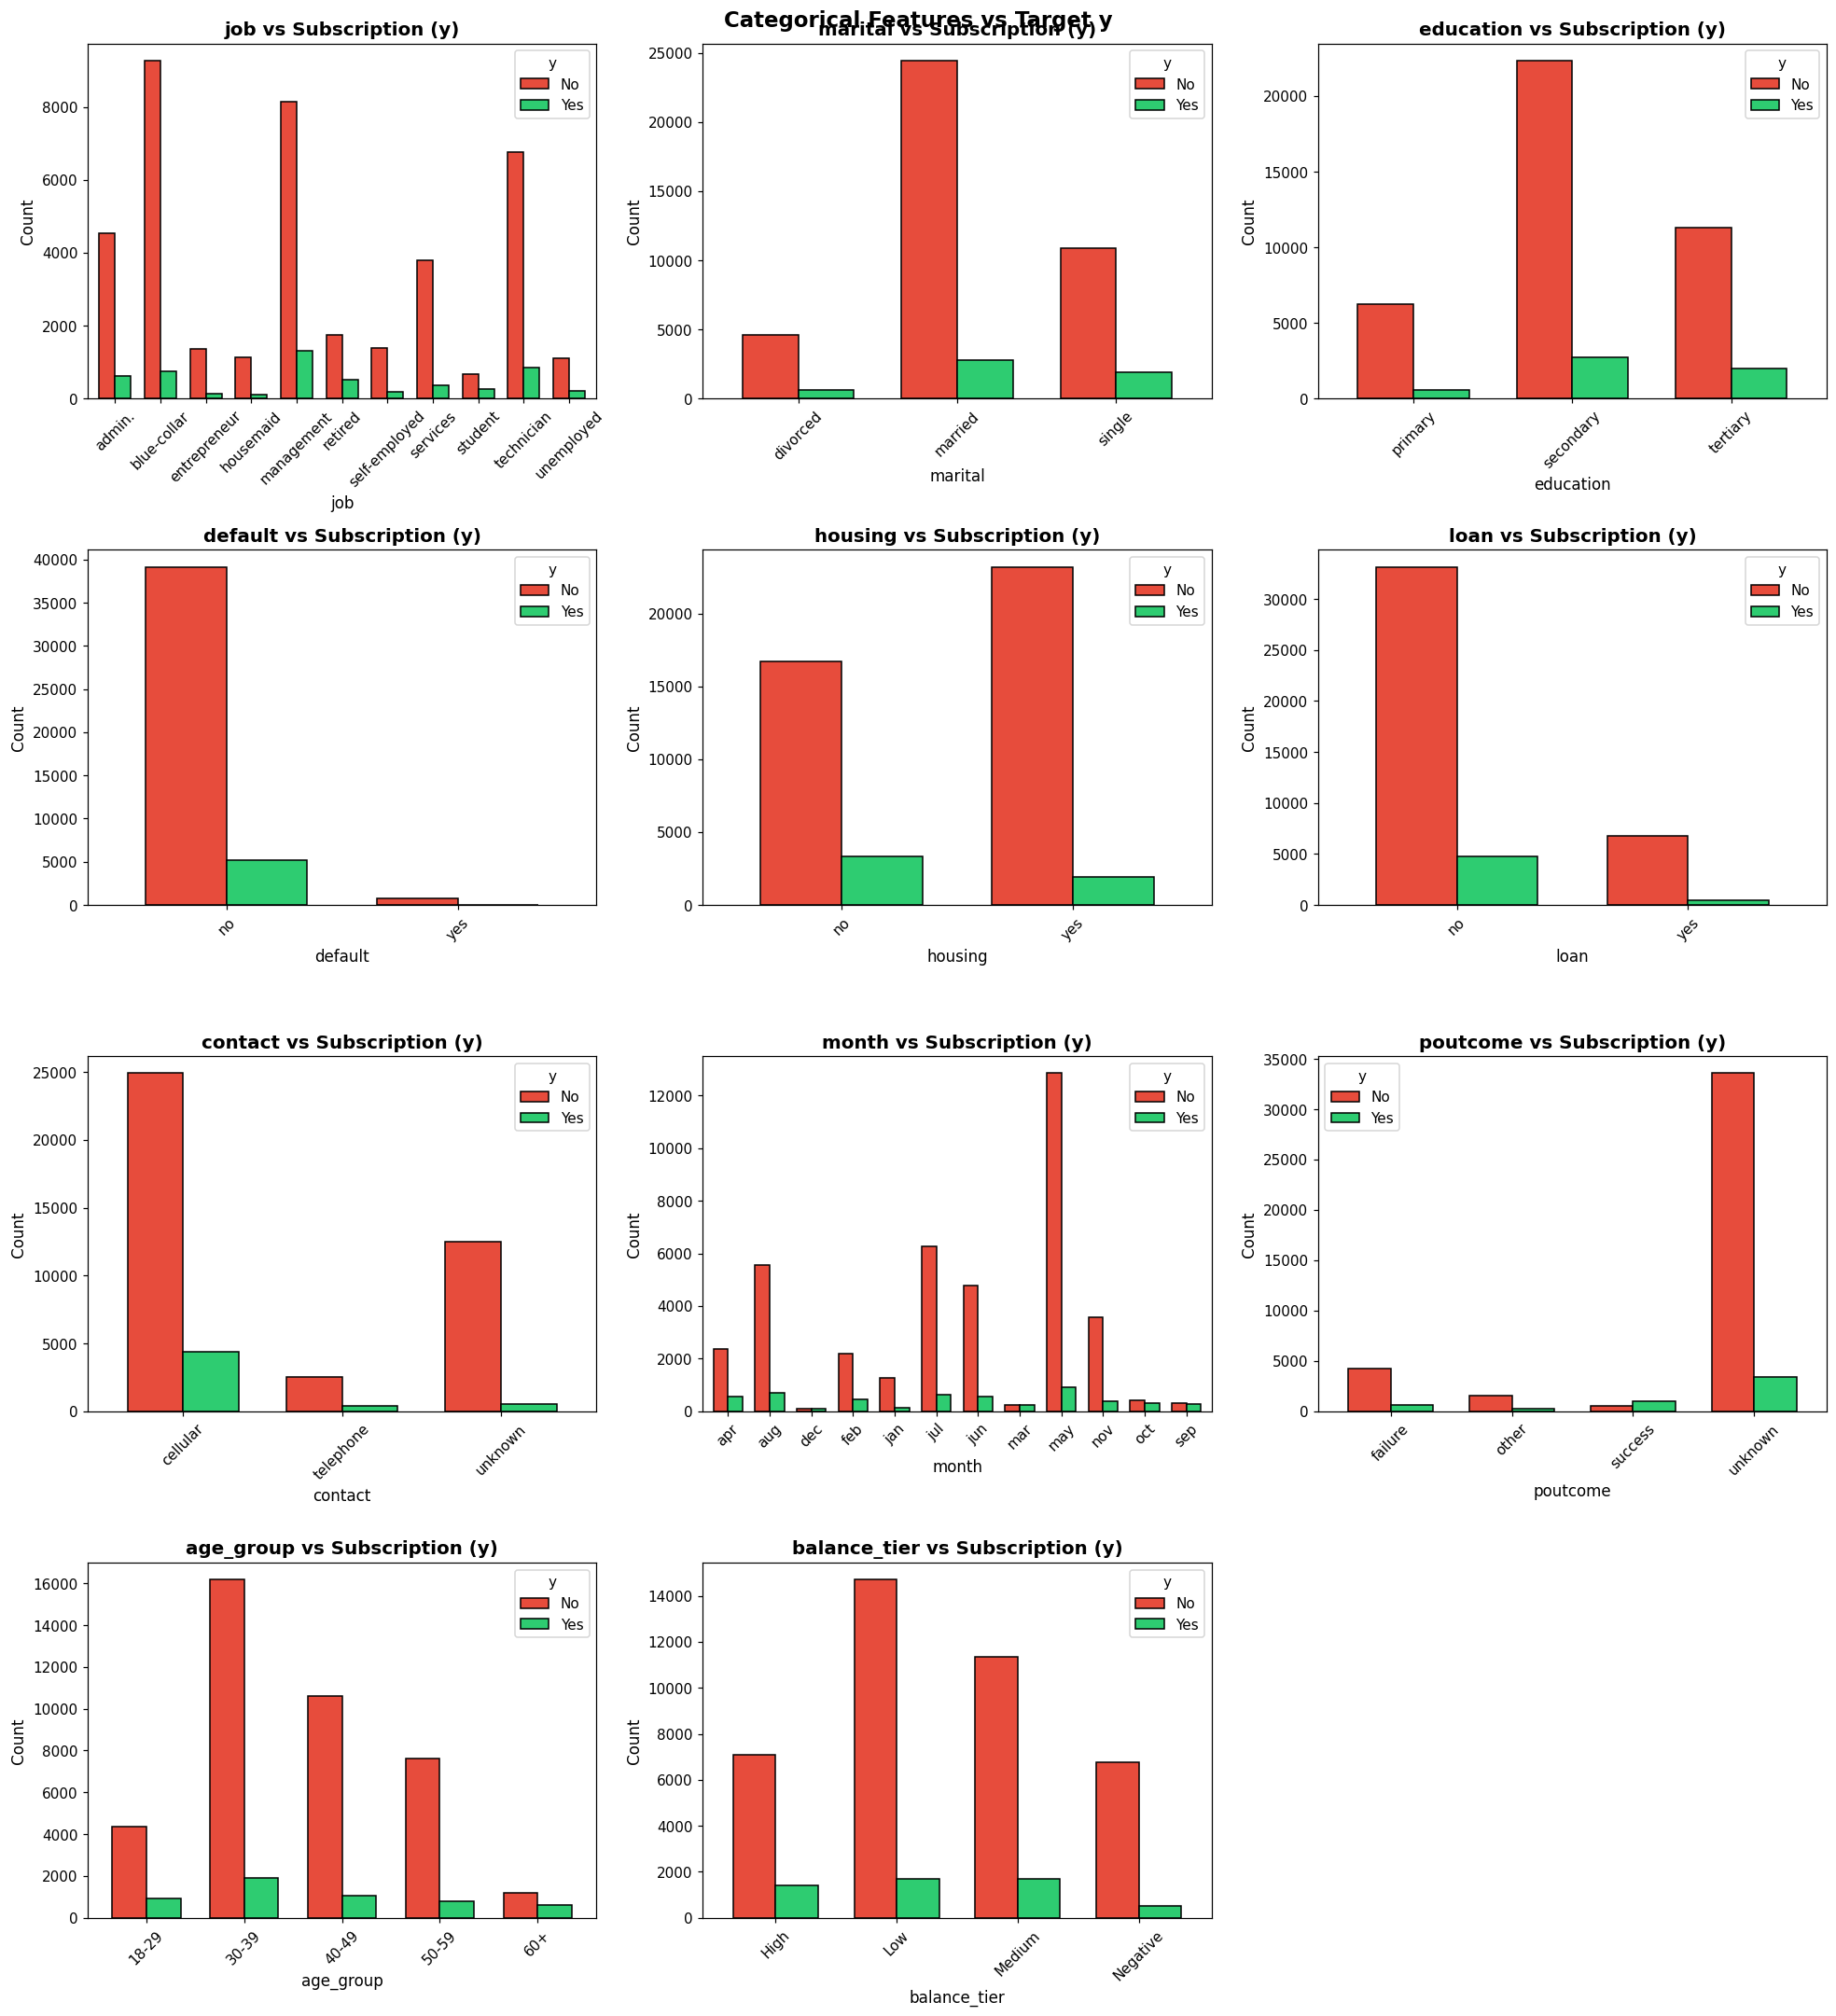

In [31]:
cat_cols = [c for c in df_viz.select_dtypes(include='object').columns if c != 'y']

rows = (len(cat_cols) + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(18, 5 * rows))
axes = axes.flatten()

colors = ['#e74c3c', '#2ecc71']

for i, col in enumerate(cat_cols):
    df_viz.groupby([col, 'y']).size().unstack().plot(
        kind='bar', ax=axes[i],
        color=colors, edgecolor='black', width=0.7
    )
    axes[i].set_title(f'{col} vs Subscription (y)', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='y', labels=['No','Yes'])

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Features vs Target y', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

<h2>6.Age Analysis</h2>
<h3>6a. Boxplot: Age vs Subscription</h3>
<p>Shows median age,spread,a dn outliers for subscribed vs non-subscribed customers.</p>

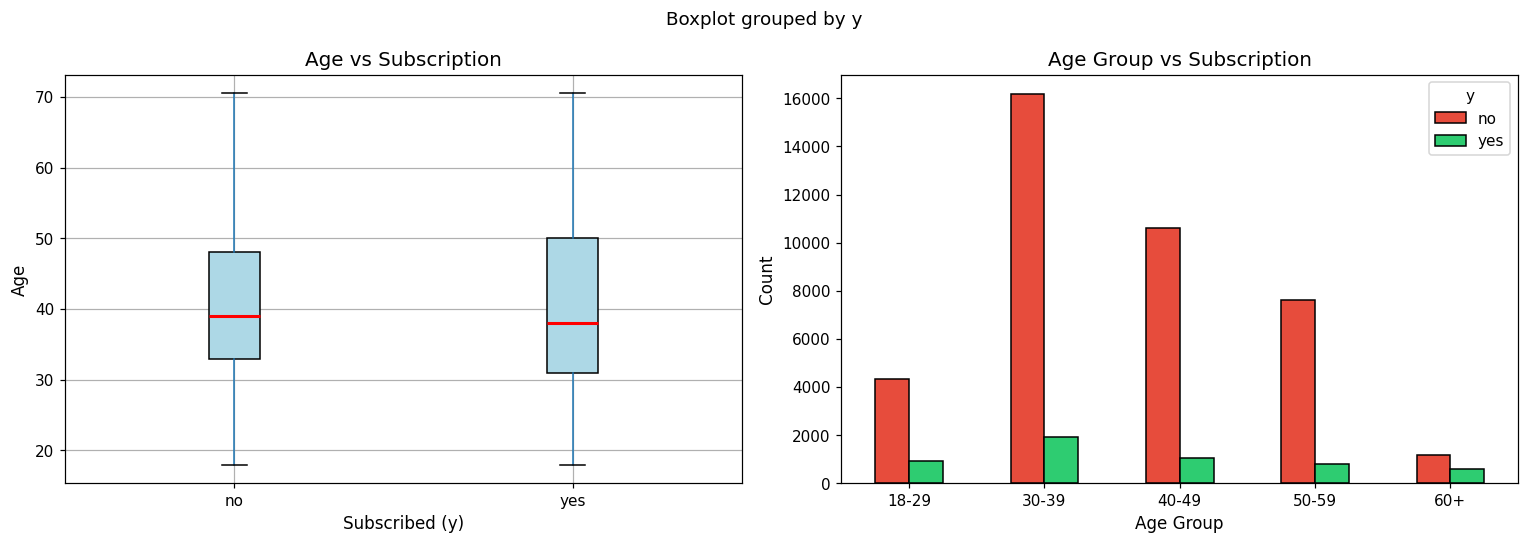

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_viz.boxplot(column='age', by='y', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Age vs Subscription')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Age')
plt.sca(axes[0]); plt.title('Age vs Subscription')

df_viz.groupby(['age_group', 'y']).size().unstack().plot(
    kind='bar', ax=axes[1],
    color=['#e74c3c','#2ecc71'], edgecolor='black'
)
axes[1].set_title('Age Group vs Subscription')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='y')

plt.tight_layout()
plt.show()

<h2>7. Balance Analysis</h2>
<p>Balance is right-skewed (some customers have very high balances).we show</p>
<p> - <bold>Box plot</bold> with log-scale to handle skew visually</p>
<p> - <bold>Mean balance</bold> per subscription group</p>
<p> - <bold>Balance </bold>tier breakdown</p>

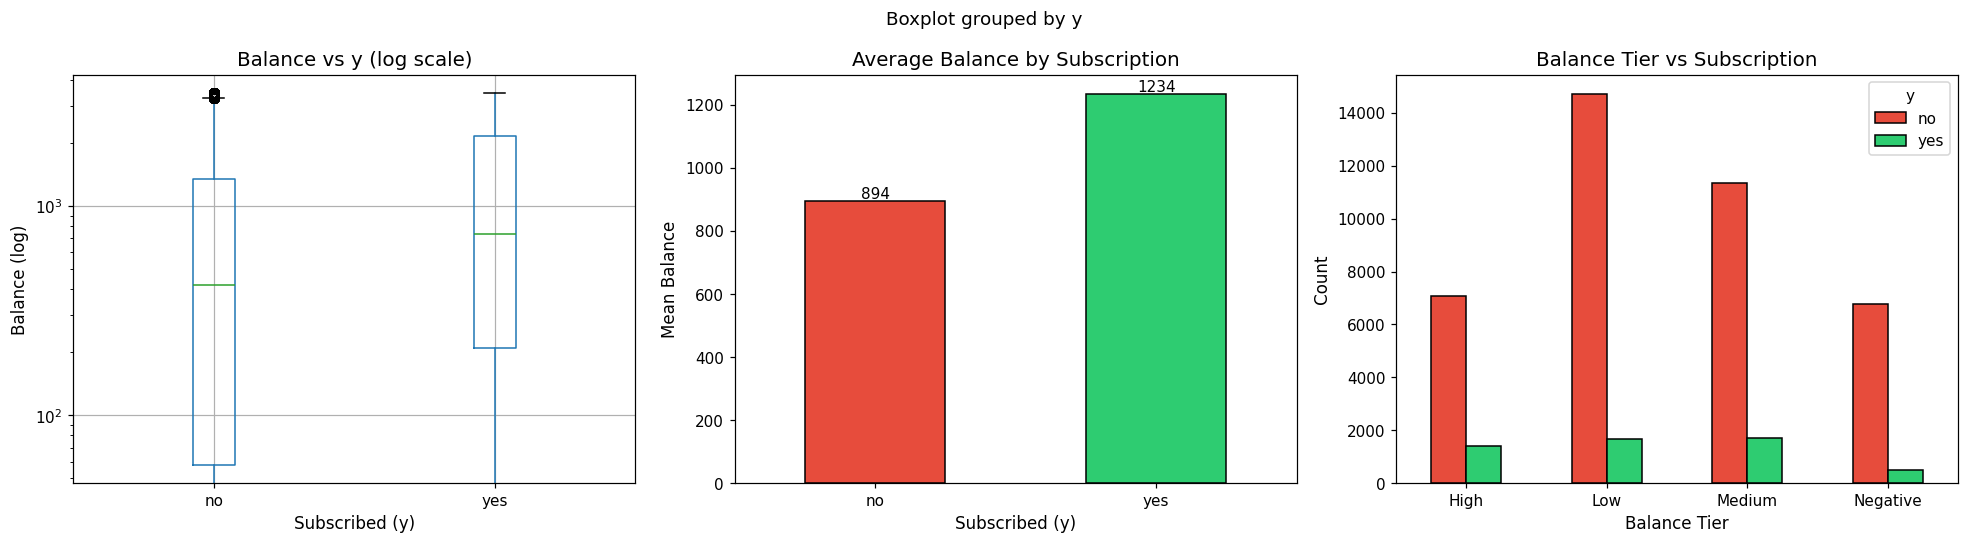

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_viz.boxplot(column='balance', by='y', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Balance vs y (log scale)')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Balance (log)')
plt.sca(axes[0]); plt.title('Balance vs y (log scale)')

df_viz.groupby('y')['balance'].mean().plot(
    kind='bar', ax=axes[1],
    color=['#e74c3c','#2ecc71'], edgecolor='black'
)
axes[1].set_title('Average Balance by Subscription')
axes[1].set_xlabel('Subscribed (y)')
axes[1].set_ylabel('Mean Balance')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0f}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

df_viz.groupby(['balance_tier','y']).size().unstack().plot(
    kind='bar', ax=axes[2],
    color=['#e74c3c','#2ecc71'], edgecolor='black'
)
axes[2].set_title('Balance Tier vs Subscription')
axes[2].set_xlabel('Balance Tier')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='y')

plt.tight_layout()
plt.show()

<h2>8. Duration Analysis</h2>
<p><bold>duration</bold> is only known after the  call ends-not useful for real-time prediction , but important for understanding subscription patterns</p>

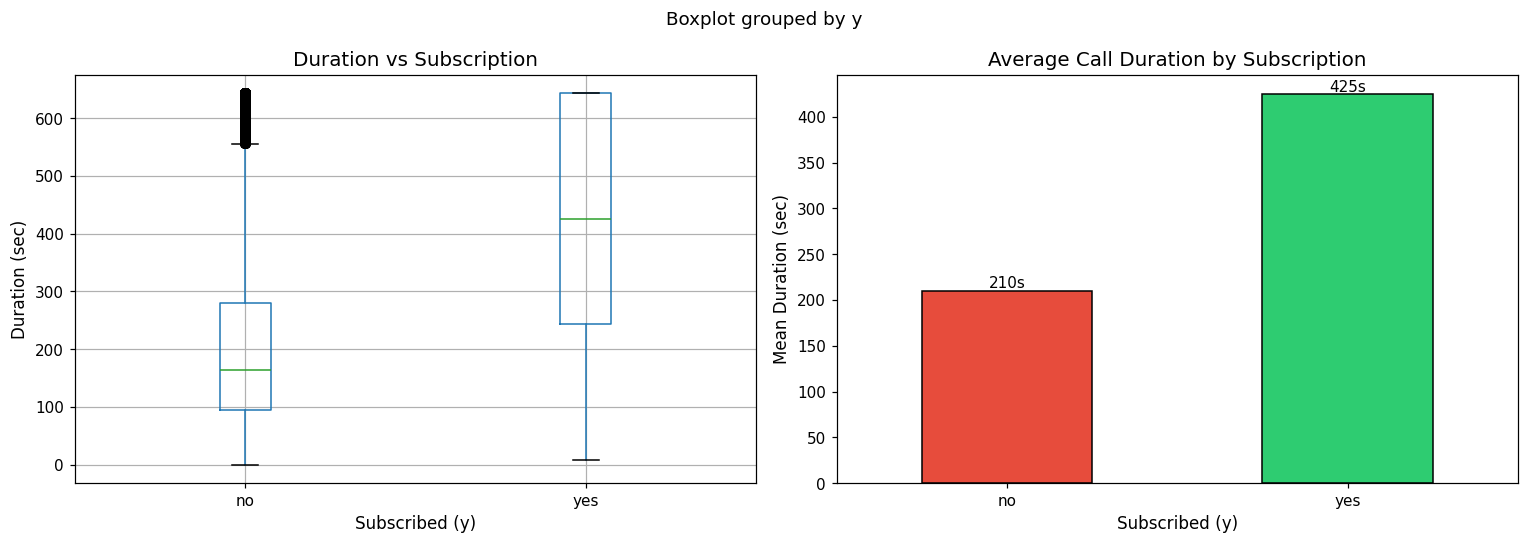

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


df_viz.boxplot(column='duration', by='y', ax=axes[0])
axes[0].set_title('Duration vs Subscription')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('Duration (sec)')
plt.sca(axes[0]); plt.title('Duration vs Subscription')

df_viz.groupby('y')['duration'].mean().plot(
    kind='bar', ax=axes[1],
    color=['#e74c3c','#2ecc71'], edgecolor='black'
)
axes[1].set_title('Average Call Duration by Subscription')
axes[1].set_xlabel('Subscribed (y)')
axes[1].set_ylabel('Mean Duration (sec)')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.0f}s',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

plt.tight_layout()
plt.show()

<h2>9.Campaign Contacts Vs Subscription</h2>
<p>Log sccale is used because most clients were contacted very few times, but a small number were contacted many times.</p>

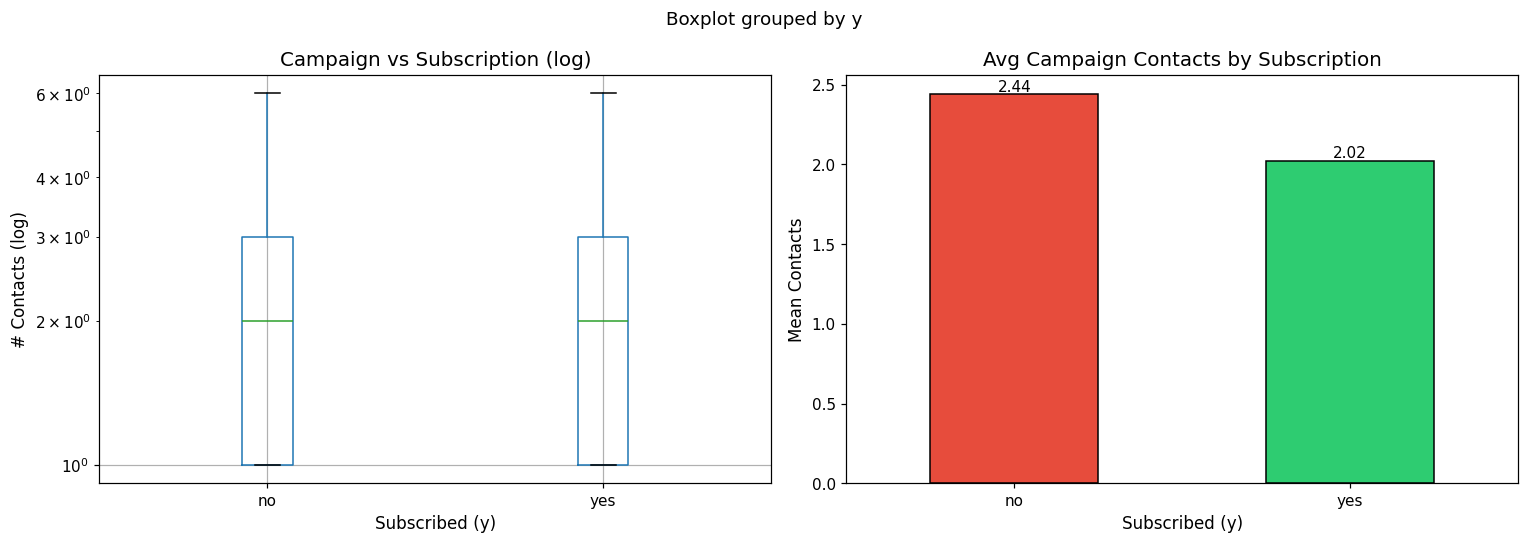

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


df_viz.boxplot(column='campaign', by='y', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Campaign vs Subscription (log)')
axes[0].set_xlabel('Subscribed (y)')
axes[0].set_ylabel('# Contacts (log)')
plt.sca(axes[0]); plt.title('Campaign vs Subscription (log)')

df_viz.groupby('y')['campaign'].mean().plot(
    kind='bar', ax=axes[1],
    color=['#e74c3c','#2ecc71'], edgecolor='black'
)
axes[1].set_title('Avg Campaign Contacts by Subscription')
axes[1].set_xlabel('Subscribed (y)')
axes[1].set_ylabel('Mean Contacts')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

plt.tight_layout()
plt.show()

<h2>10.Monthly Subscription Trend(Line Plot)</h2>
<p>Chronologically sorted using <u>month_num</u> from featiure engineering. Reveals which months had the most marketing activity and highest subscription rates.</p>

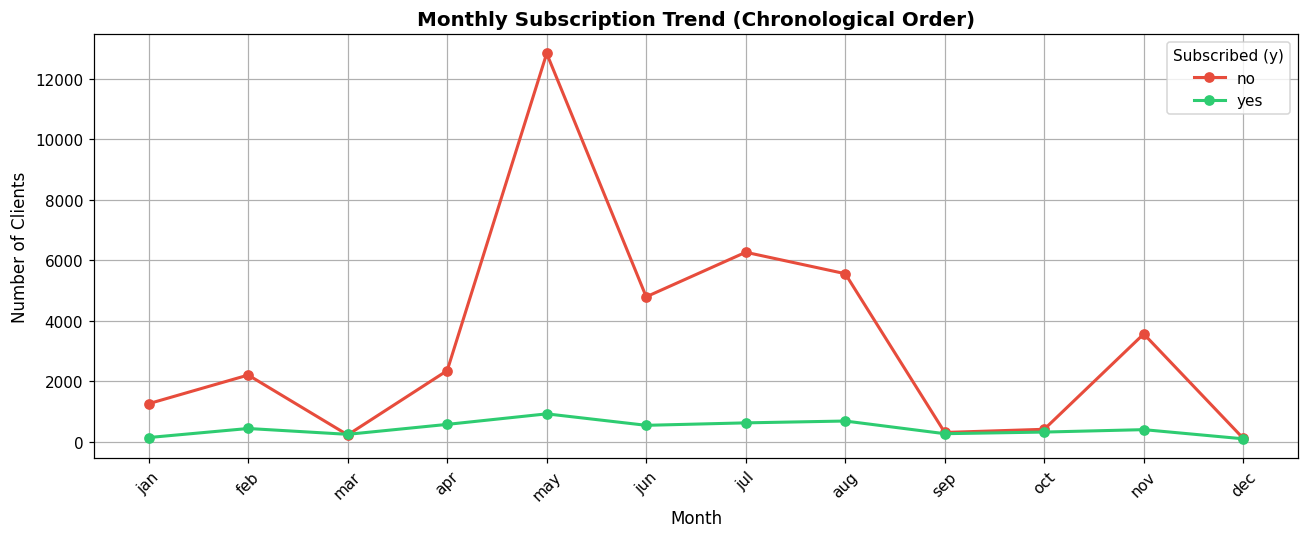

In [7]:
month_data = (
    df_viz.groupby(['month_num', 'month', 'y'])
      .size()
      .reset_index(name='count')
      .sort_values('month_num')
)

pivot = month_data.pivot_table(index=['month_num','month'], columns='y', values='count').reset_index()
pivot.index = pivot['month']  

fig, ax = plt.subplots(figsize=(12, 5))
pivot[['no','yes']].plot(
    kind='line', ax=ax,
    marker='o', color=['#e74c3c','#2ecc71'],
    linewidth=2, markersize=6, grid=True
)
ax.set_xticks(range(len(pivot)))
ax.set_xticklabels(pivot['month'].tolist(), rotation=45)
ax.set_title('Monthly Subscription Trend (Chronological Order)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Clients')
ax.legend(title='Subscribed (y)')
plt.tight_layout()
plt.show()

<h2>11. Day of Month & Previous Outcome Vs Subscription</h2>

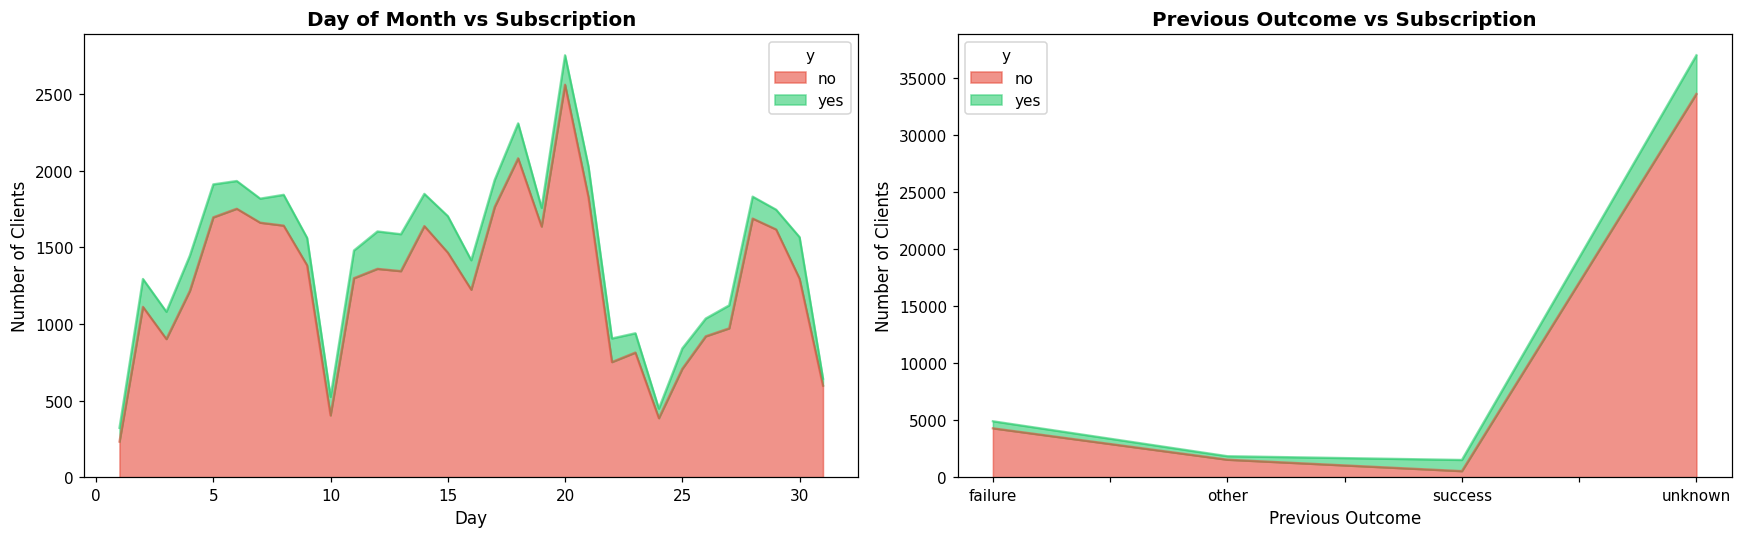

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_viz.groupby(['day','y']).size().unstack().plot(
    kind='area', ax=axes[0],
    stacked=True, alpha=0.6,
    color=['#e74c3c','#2ecc71']
)
axes[0].set_title('Day of Month vs Subscription', fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Number of Clients')
axes[0].legend(title='y')

df_viz.groupby(['poutcome','y']).size().unstack().plot(
    kind='area', ax=axes[1],
    stacked=True, alpha=0.6,
    color=['#e74c3c','#2ecc71']
)
axes[1].set_title('Previous Outcome vs Subscription', fontweight='bold')
axes[1].set_xlabel('Previous Outcome')
axes[1].set_ylabel('Number of Clients')
axes[1].legend(title='y')

plt.tight_layout()
plt.show()

<h2>12. Previous Contacts & Contact Type</h2>


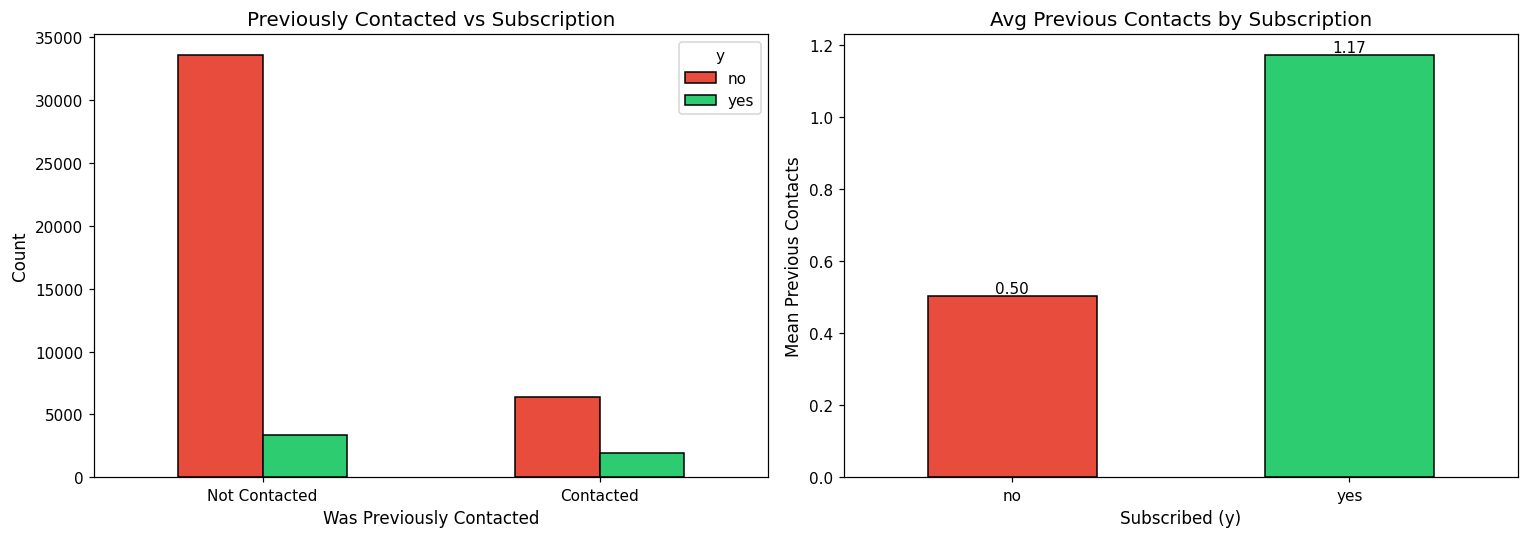

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_viz.groupby(['was_previously_contacted','y']).size().unstack().plot(
    kind='bar', ax=axes[0],
    color=['#e74c3c','#2ecc71'], edgecolor='black'
)
axes[0].set_title('Previously Contacted vs Subscription')
axes[0].set_xticklabels(['Not Contacted','Contacted'], rotation=0)
axes[0].set_xlabel('Was Previously Contacted')
axes[0].set_ylabel('Count')
axes[0].legend(title='y')

df_viz.groupby('y')['previous'].mean().plot(
    kind='bar', ax=axes[1],
    color=['#e74c3c','#2ecc71'], edgecolor='black'
)
axes[1].set_title('Avg Previous Contacts by Subscription')
axes[1].set_xlabel('Subscribed (y)')
axes[1].set_ylabel('Mean Previous Contacts')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.2f}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

plt.tight_layout()
plt.show()

<h2>13. Scatter & Bubble Plots
<h3>13a. Age Vs Balance(coloured by subscription)</h3>
<h3>13b. Bubble plot: Age Vs Balance, size=Duration</h3>

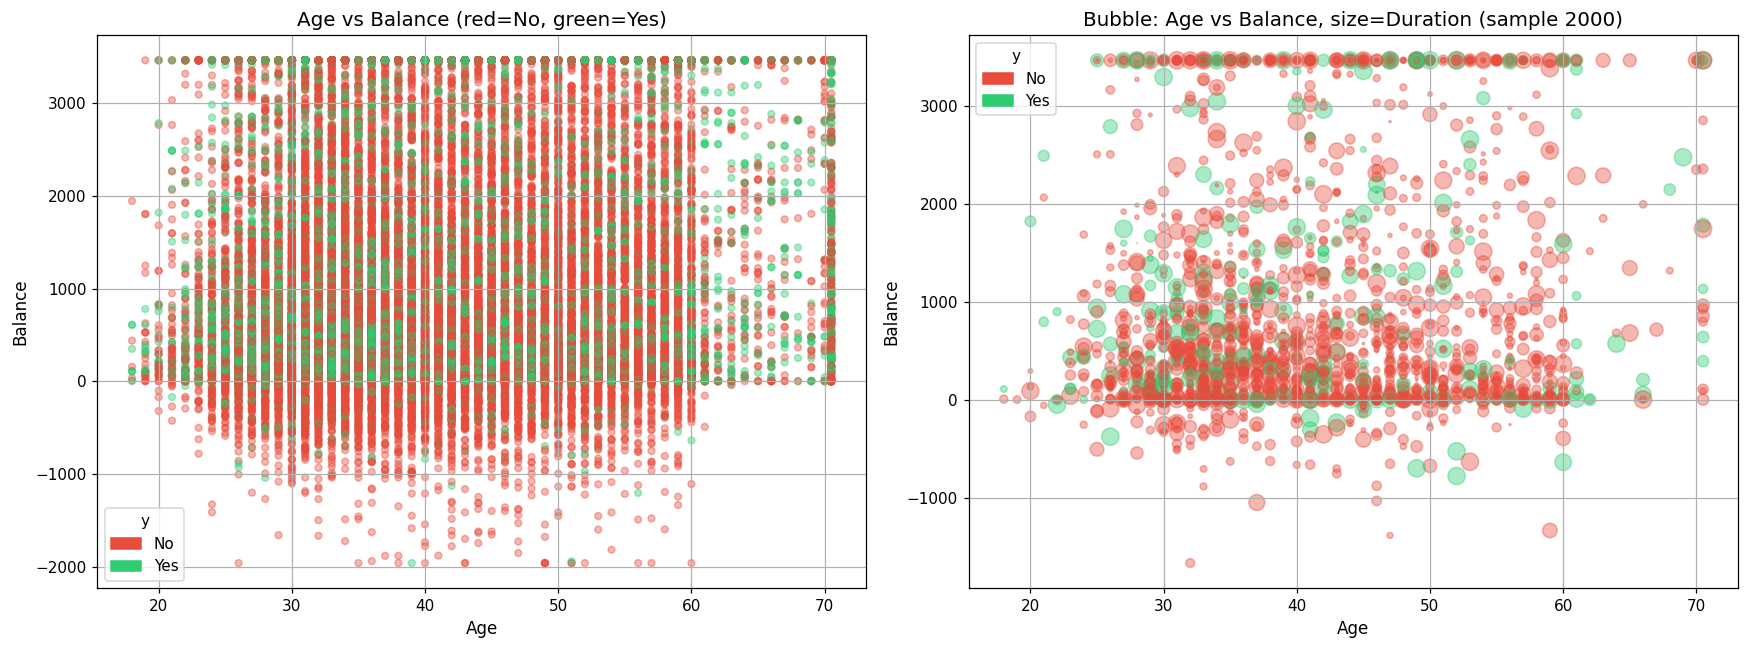

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = df_viz['y'].map({'no': '#e74c3c', 'yes': '#2ecc71'})


df_viz.plot.scatter(
    x='age', y='balance',
    c=colors, alpha=0.4,
    ax=axes[0], grid=True
)
axes[0].set_title('Age vs Balance (red=No, green=Yes)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Balance')

sample = df_viz.sample(2000, random_state=42)
s_colors = sample['y'].map({'no': '#e74c3c', 'yes': '#2ecc71'})
sample.plot.scatter(
    x='age', y='balance',
    s=sample['duration'] / 5,
    c=s_colors, alpha=0.4,
    ax=axes[1], grid=True
)
axes[1].set_title('Bubble: Age vs Balance, size=Duration (sample 2000)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Balance')

for ax in axes:
    handles = [
        mpatches.Patch(color='#e74c3c', label='No'),
        mpatches.Patch(color='#2ecc71', label='Yes')
    ]
    ax.legend(handles=handles, title='y')

plt.tight_layout()
plt.show()

<h2>14. Regression Plots(Seaborn)</h2>
<p> Using a random sample of 300 rows from df_viz for readability</p>

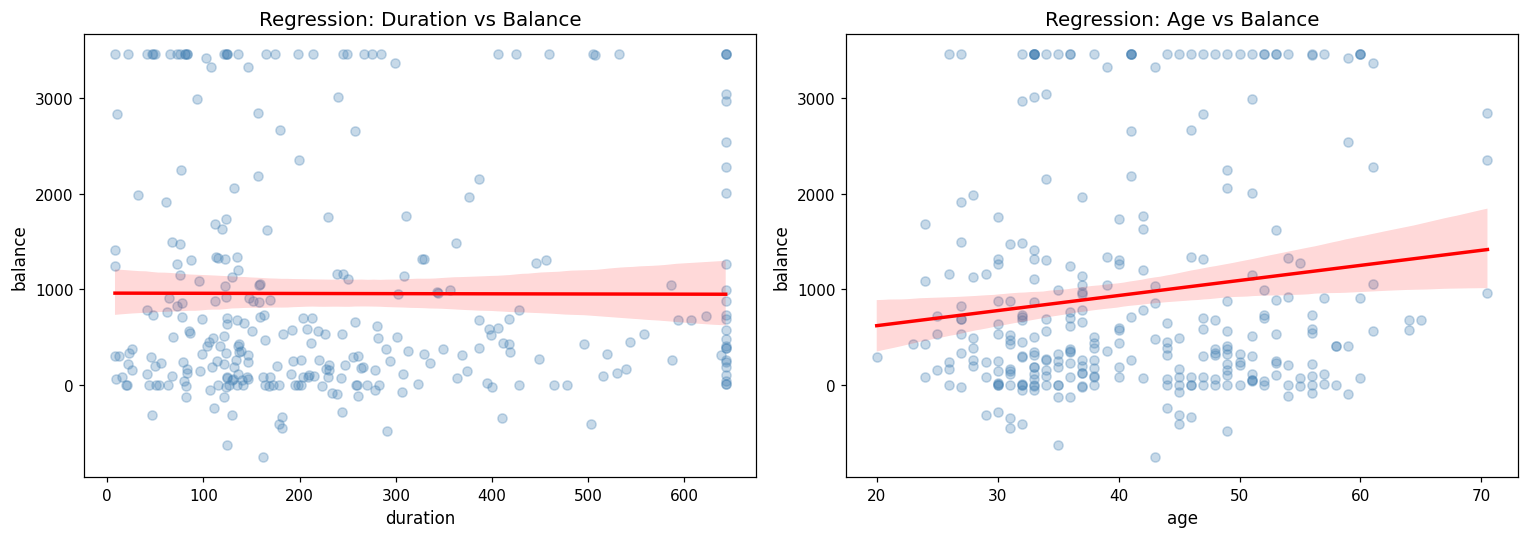

In [11]:
sample = df_viz.sample(300, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(x='duration', y='balance', data=sample,
            scatter_kws={'alpha': 0.3, 'color':'steelblue'},
            line_kws={'color':'red'}, ax=axes[0])
axes[0].set_title('Regression: Duration vs Balance')

sns.regplot(x='age', y='balance', data=sample,
            scatter_kws={'alpha': 0.3, 'color':'steelblue'},
            line_kws={'color':'red'}, ax=axes[1])
axes[1].set_title('Regression: Age vs Balance')

plt.tight_layout()
plt.show()

<h2>15. Job Distribution- Pie Chart & Word Cloud</h2>

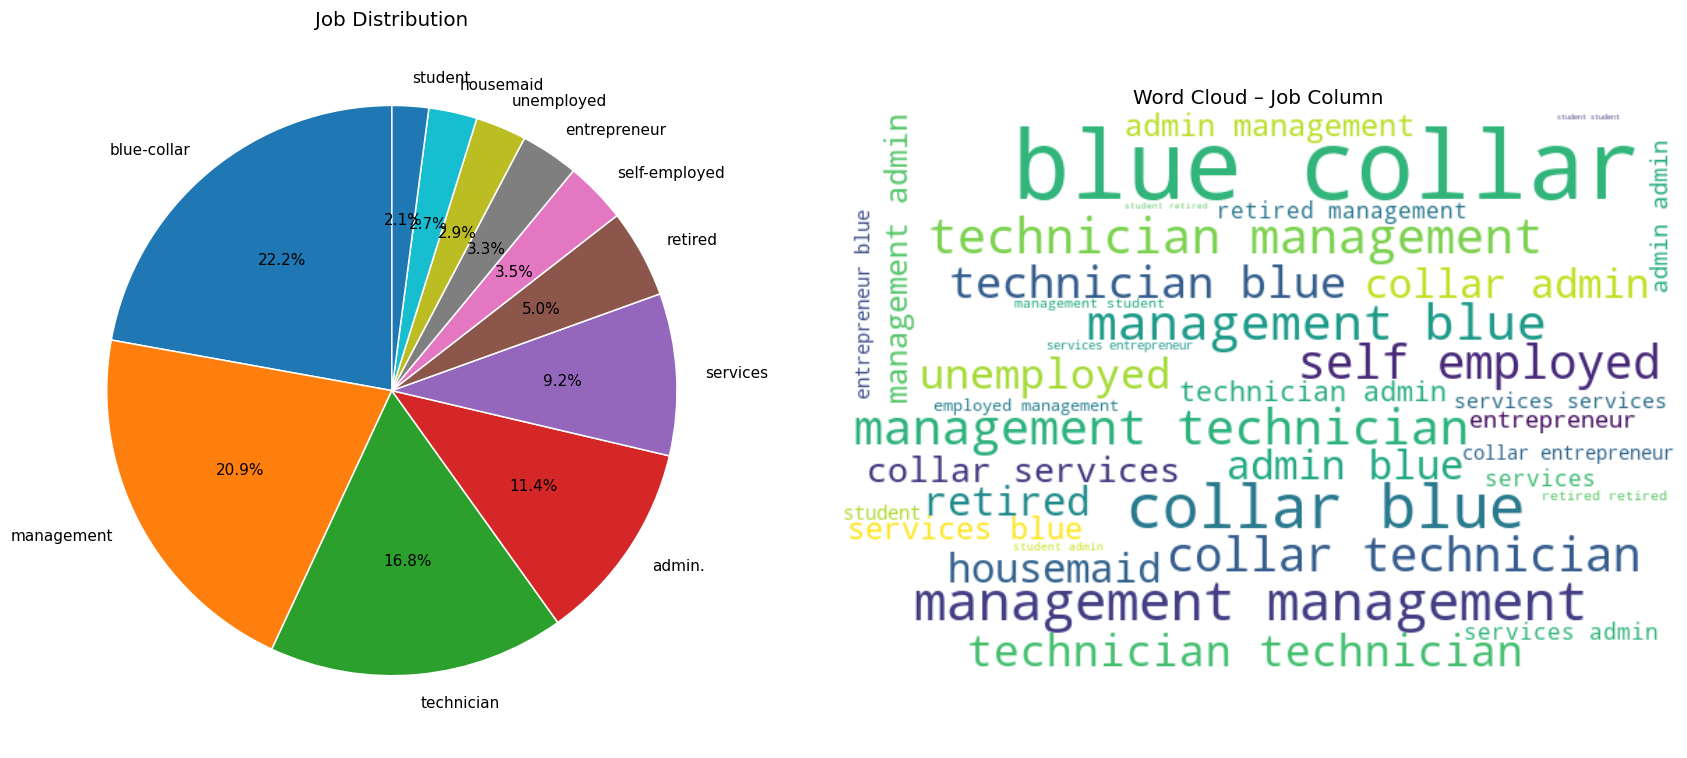

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

df_viz['job'].value_counts().plot(
    kind='pie', ax=axes[0],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)
axes[0].set_title('Job Distribution')
axes[0].set_ylabel('')

# Word cloud------>
try:
    from wordcloud import WordCloud
    text = ' '.join(df_viz['job'].astype(str))
    wc = WordCloud(width=600, height=400, background_color='white').generate(text)
    axes[1].imshow(wc, interpolation='bilinear')
    axes[1].axis('off')
    axes[1].set_title('Word Cloud – Job Column')
except ImportError:
    axes[1].text(0.5, 0.5, 'Install wordcloud:\npip install wordcloud',
                 ha='center', va='center', fontsize=13)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

<h2>16. Waffle Chart - Target (y)</h2>
<p>Proportion of subscribed vs non-subscribed customers shown as a grid of tiles.</p>

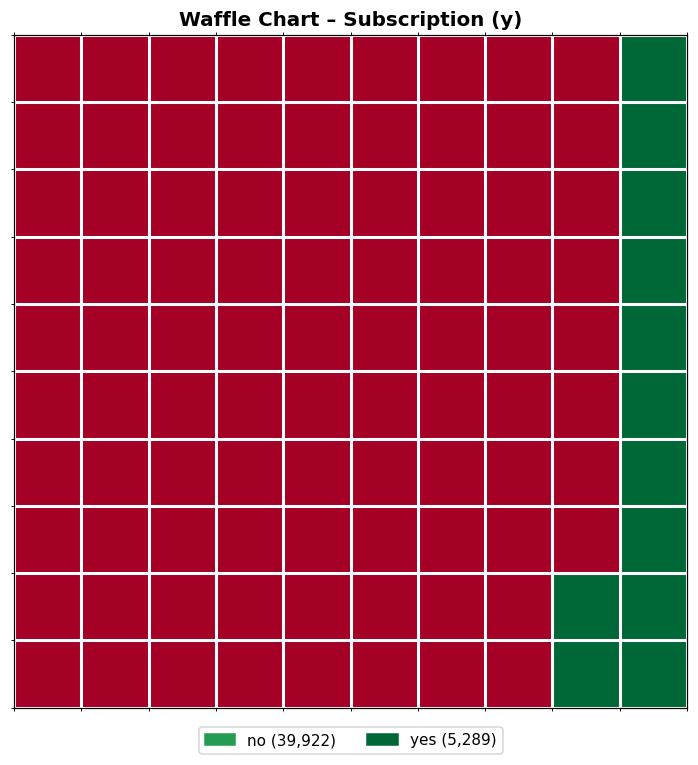

In [15]:
def waffle_chart(df_col, height=10, width=10, colormap=plt.cm.RdYlGn):
    counts = df_col.value_counts()
    categories = counts.index.tolist()
    values = counts.values.tolist()

    total_tiles = width * height
    proportions = [v / sum(values) for v in values]
    tiles = [round(p * total_tiles) for p in proportions]

    chart = np.zeros((height, width))
    cat_idx, tile_idx = 0, 0
    for col in range(width):
        for row in range(height):
            tile_idx += 1
            if tile_idx > sum(tiles[:cat_idx + 1]):
                cat_idx += 1
            chart[row, col] = cat_idx

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.matshow(chart, cmap=colormap)
    ax.set_xticks(np.arange(-.5, width, 1), minor=True)
    ax.set_yticks(np.arange(-.5, height, 1), minor=True)
    ax.grid(which='minor', color='w', linestyle='-', linewidth=2)
    ax.set_xticks([]); ax.set_yticks([])

    cum = np.cumsum(values)
    handles = []
    for i, cat in enumerate(categories):
        color = colormap(cum[i] / cum[-1])
        handles.append(mpatches.Patch(color=color,
                                       label=f'{cat} ({values[i]:,})'))
    ax.legend(handles=handles, loc='lower center', ncol=len(categories),
              bbox_to_anchor=(0.5, -0.08))
    ax.set_title('Waffle Chart – Subscription (y)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

waffle_chart(df_viz['y'])

<h2>17. Correlation Heatmap</h2>
<p>Shows pairwise correlation between all numerica columns. Strong positive(red) or negative(blue) values indicate related features.</p>

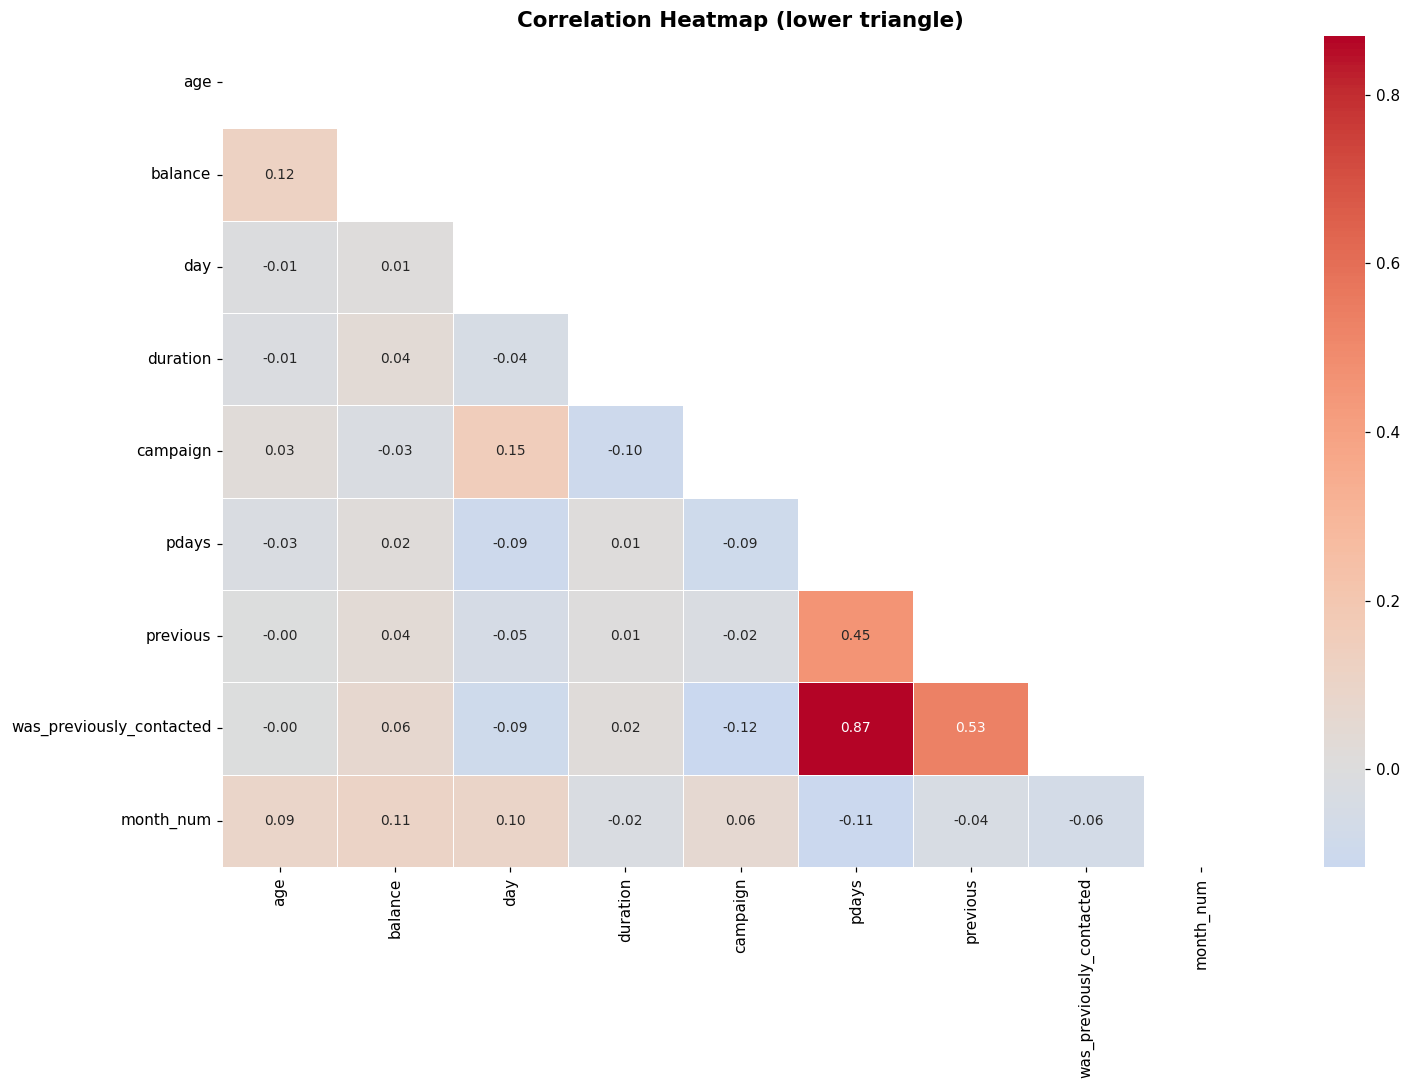

In [16]:
corr = df_viz.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool)) 
sns.heatmap(
    corr, annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    mask=mask,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}
)
plt.title('Correlation Heatmap (lower triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<h2>18. Save Final Visualised Dataset</h2>

In [17]:
df_viz.to_csv('final_visualization.csv',index=False)
print(f'Saved: final_visualization.csv | Shape: {df_viz.shape}')

Saved: final_visualization.csv | Shape: (45211, 21)
